In [2]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
from src.db import get_connection

con = get_connection(read_only=True)
print("Connection Established :)") 

Connection Established :)


In [3]:
# ── Intervention Target Parameters ───────────────────────────────────────
# Adjust these to model different scenarios.
# Each pair represents (current_state, intervention_target).

# Radiology — prior auth obtain rate
RADIOLOGY_AUTH_CURRENT = 0.68
RADIOLOGY_AUTH_TARGET  = 0.85

# Internal Medicine — timely filing miss rate (% of claims breaching window)
IM_FILING_MISS_CURRENT = 0.07
IM_FILING_MISS_TARGET  = 0.02   # residual — some late captures are unavoidable

# Emergency — coding accuracy rate
EMERGENCY_CODING_CURRENT = 0.78
EMERGENCY_CODING_TARGET  = 0.90

# Behavioral Health — credentialing lapse rate
BH_CRED_LAPSE_CURRENT = 0.12
BH_CRED_LAPSE_TARGET  = 0.03

# ── Implementation Complexity Proxy (1=easy → 5=hard) ────────────────────
# Used for prioritization matrix. Adjust based on your org's capacity.
COMPLEXITY = {
    "Auth Workflow (CO-57)":       2,   # scheduling checklist, staff training
    "Charge Lag Process (CO-29)":  3,   # billing culture change, EMR workflow
    "Coding Accuracy (CO-4)":      3,   # coder education + CDI program
    "Credentialing Renewal (CO-B7)": 1, # calendar alerts, re-credentialing tracker
}

print("Parameters loaded. Adjust variables above to model different scenarios.")

Parameters loaded. Adjust variables above to model different scenarios.


------
#### Chapter 1 · Failure Node Baseline

###### Question: What is the current dollar exposure by upstream failure node?

###### Before modeling any intervention, establish what each failure node costs. This is the number the intervention has to beat.

In [4]:
baseline = con.execute("""
    SELECT
        df.upstream_failure_node,
        df.denial_category,
        df.carc_code,
        COUNT(*)                            AS denial_count,
        ROUND(SUM(df.dollars_at_risk), 2)   AS total_dollars_at_risk,
        ROUND(AVG(df.dollars_at_risk), 2)   AS avg_denial_amount,
        ROUND(AVG(df.recovery_probability), 3) AS avg_recovery_prob,
        ROUND(SUM(df.dollars_at_risk * df.recovery_probability), 2) AS expected_recoverable
    FROM denial_forensics df
    GROUP BY df.upstream_failure_node, df.denial_category, df.carc_code
    ORDER BY total_dollars_at_risk DESC
""").df()

print("Denial Baseline by Failure Node\n")
print(baseline.to_string(index=False))

Denial Baseline by Failure Node

upstream_failure_node          denial_category carc_code  denial_count  total_dollars_at_risk  avg_denial_amount  avg_recovery_prob  expected_recoverable
               coding             coding_error      CO-4          3276             3981335.76            1215.30               0.70            2786935.03
  prior_authorization            authorization     CO-57          1281             2986941.52            2331.73               0.55            1642817.84
  prior_authorization        medical_necessity     CO-50           759             1903690.02            2508.16               0.35             666291.51
              billing      missing_information     CO-16          1591             1680743.15            1056.41               0.72            1210135.07
               coding                 bundling     CO-97           634              836811.06            1319.89               0.65             543927.19
   remittance_posting coordination_of_benef

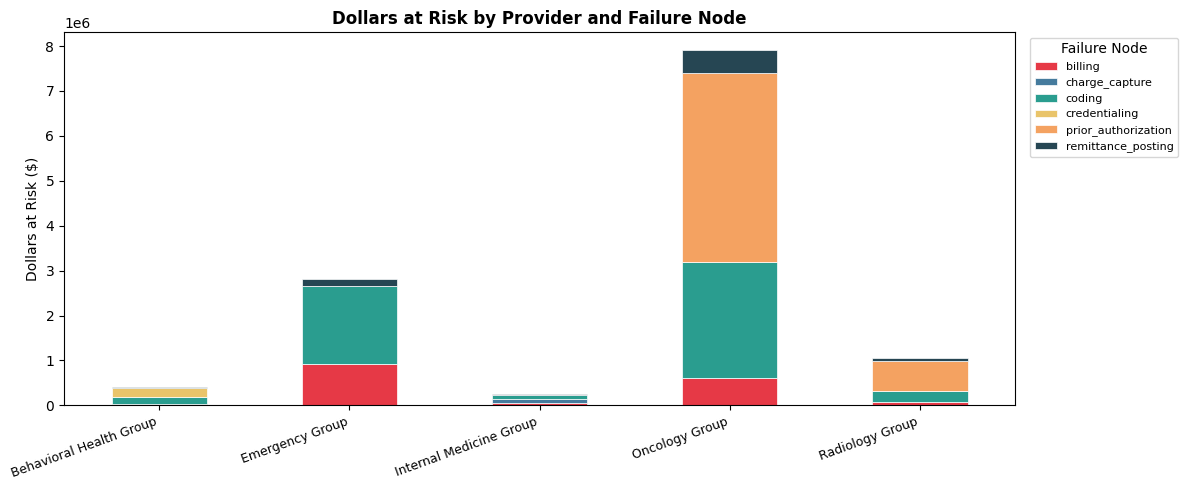

In [5]:
provider_baseline = con.execute("""
    SELECT
        p.practice_name,
        p.persona_type,
        df.upstream_failure_node,
        df.carc_code,
        COUNT(*)                          AS denial_count,
        ROUND(SUM(df.dollars_at_risk), 2) AS dollars_at_risk
    FROM denial_forensics df
    JOIN remittance_835 r  ON df.claim_line_id = r.claim_line_id
    JOIN claim_header ch   ON r.claim_id = ch.claim_id
    JOIN provider p        ON ch.provider_id = p.provider_id
    GROUP BY p.practice_name, p.persona_type, df.upstream_failure_node, df.carc_code
    ORDER BY dollars_at_risk DESC
""").df()

# Stacked bar: dollars at risk by provider and failure node
pivot = provider_baseline.pivot_table(
    index="practice_name", columns="upstream_failure_node",
    values="dollars_at_risk", aggfunc="sum"
).fillna(0)

colors = ["#e63946", "#457b9d", "#2a9d8f", "#e9c46a", "#f4a261", "#264653"]
ax = pivot.plot(kind="bar", stacked=True, figsize=(12, 5),
                color=colors[:len(pivot.columns)], edgecolor="white", linewidth=0.5)
ax.set_title("Dollars at Risk by Provider and Failure Node", fontsize=12, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Dollars at Risk ($)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right", fontsize=9)
ax.legend(title="Failure Node", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

#### Chapter 2 · CO-57 Root Cause Sub-Classification

###### Question:** What is actually driving CO-57 — before the model runs?

###### This matters because the counterfactual in Section 3 assumes CO-57 denials are driven by auth not being obtained. If denials include cases where auth was obtained but the details didn't match (wrong procedure code, wrong date, wrong provider), the obtain-rate model will overstate recovery.
###### Sub-classify first. Then decide which intervention to target.

In [6]:
co57_subclass = con.execute("""
    SELECT
        p.practice_name,
        ch.payer_id,
        COUNT(*)                                                       AS co57_denials,
        SUM(df.dollars_at_risk)                                        AS dollars_at_risk,
        -- Sub-classification: auth not obtained vs obtained retroactively
        SUM(CASE WHEN ec.prior_auth_obtained = FALSE
                  OR ec.prior_auth_obtained IS NULL THEN 1 ELSE 0 END) AS auth_not_obtained,
        SUM(CASE WHEN ec.prior_auth_obtained = TRUE
                  AND ec.auth_request_date > ec.date_of_service
                 THEN 1 ELSE 0 END)                                    AS auth_obtained_late,
        SUM(CASE WHEN ec.prior_auth_obtained = TRUE
                  AND (ec.auth_request_date <= ec.date_of_service
                       OR ec.auth_request_date IS NULL)
                 THEN 1 ELSE 0 END)                                    AS auth_obtained_timely
    FROM denial_forensics df
    JOIN remittance_835 r  ON df.claim_line_id = r.claim_line_id
    JOIN claim_header ch   ON r.claim_id = ch.claim_id
    JOIN provider p        ON ch.provider_id = p.provider_id
    JOIN encounter_context ec ON ch.claim_id = ec.claim_id
    WHERE df.carc_code = 'CO-57'
    GROUP BY p.practice_name, ch.payer_id
    ORDER BY dollars_at_risk DESC
""").df()

print("CO-57 Root Cause Sub-Classification\n")
print(co57_subclass.to_string(index=False))

total = co57_subclass["co57_denials"].sum()
not_obtained = co57_subclass["auth_not_obtained"].sum()
late = co57_subclass["auth_obtained_late"].sum()
timely = co57_subclass["auth_obtained_timely"].sum()

print(f"\nAttribution Summary:")
print(f"  Auth not obtained:    {not_obtained:>6} ({100*not_obtained/total:.1f}%) → obtain-rate intervention")
print(f"  Auth obtained late:   {late:>6} ({100*late/total:.1f}%) → scheduling/timing intervention")
print(f"  Auth obtained timely: {timely:>6} ({100*timely/total:.1f}%) → documentation/matching issue")
print(f"\nNote: Section 3 counterfactual targets the 'auth not obtained' bucket only.")
print(f"If late/matching buckets are material, a separate intervention model is needed.")

CO-57 Root Cause Sub-Classification

  practice_name               payer_id  co57_denials  dollars_at_risk  auth_not_obtained  auth_obtained_late  auth_obtained_timely
 Oncology Group  medi_cal_managed_care           381       1645542.82              381.0                 0.0                   0.0
 Oncology Group     medicare_advantage           113        435660.33              113.0                 0.0                   0.0
 Oncology Group         commercial_ppo            89        407401.26               89.0                 0.0                   0.0
Radiology Group  medi_cal_managed_care           463        290287.80              463.0                 0.0                   0.0
Radiology Group     medicare_advantage           108         67956.40              108.0                 0.0                   0.0
 Oncology Group dual_eligible_cobpayer            17         63782.95               17.0                 0.0                   0.0
Radiology Group         commercial_ppo        

In [7]:
# Retroactive auth: encounters where auth WAS obtained but after service date
# These did NOT generate CO-57 this period — but represent process fragility.
# If payer policy on retroactive auth tightens, these become denials.

retro_auth_risk = con.execute("""
    SELECT
        p.practice_name,
        COUNT(ec.encounter_id)                                           AS retro_auth_encounters,
        ROUND(100.0 * COUNT(ec.encounter_id) /
              SUM(COUNT(ec.encounter_id)) OVER (), 1)                   AS pct_of_total_retro,
        ROUND(AVG(
            date_diff('day', ec.date_of_service, ec.auth_request_date)
        ), 1)                                                            AS avg_days_late
    FROM encounter_context ec
    JOIN claim_header ch ON ec.claim_id = ch.claim_id
    JOIN provider p      ON ch.provider_id = p.provider_id
    WHERE ec.prior_auth_required = TRUE
      AND ec.prior_auth_obtained = TRUE
      AND ec.auth_request_date > ec.date_of_service
    GROUP BY p.practice_name
    ORDER BY retro_auth_encounters DESC
""").df()

print("Retroactive Auth Risk — Process Fragility Signal (not currently denied, but at risk)\n")
print(retro_auth_risk.to_string(index=False))

Retroactive Auth Risk — Process Fragility Signal (not currently denied, but at risk)

  practice_name  retro_auth_encounters  pct_of_total_retro  avg_days_late
Radiology Group                    490                55.9            7.0
 Oncology Group                    387                44.1            7.2


-------
#### Chapter 3 · Counterfactual Intervention Models
###### Question: If we moved rate X to Y, what would we recover?

###### Each model follows the same logic:
###### 1. Fetch the current denial baseline for that failure node
###### 2. Apply the reduction fraction derived from the parameter targets above
###### 3. Project denials avoided and dollars recovered

###### Reduction formula:`fraction_avoided = (target - current) / (headroom)`  
###### where headroom is the maximum improvable portion of the problem.

###### Adjust the variables in the setup cell to model different intervention intensities.


In [8]:
# ── CO-57 · Radiology Auth Obtain Rate ──────────────────────────────────
# Intervention: scheduling checkpoint + auth-required CPT flag at time of order
# Targets: encounters where auth was required but never obtained

co57_base = con.execute("""
    SELECT
        COUNT(*)                          AS total_co57_denials,
        ROUND(SUM(df.dollars_at_risk), 2) AS total_co57_dollars
    FROM denial_forensics df
    JOIN remittance_835 r ON df.claim_line_id = r.claim_line_id
    JOIN claim_header ch  ON r.claim_id = ch.claim_id
    JOIN provider p       ON ch.provider_id = p.provider_id
    WHERE df.carc_code = 'CO-57'
      AND p.persona_type = 'prior_auth_miss'
""").df()

co57_count   = co57_base["total_co57_denials"].iloc[0]
co57_dollars = co57_base["total_co57_dollars"].iloc[0]

# Fraction of current misses that the intervention would fix
# Logic: of all encounters that currently miss auth (32%), intervention
# moves 17pp to obtaining → 17/32 = 53.1% of CO-57 denials disappear
co57_headroom         = 1 - RADIOLOGY_AUTH_CURRENT
co57_reduction_frac   = (RADIOLOGY_AUTH_TARGET - RADIOLOGY_AUTH_CURRENT) / co57_headroom
co57_denials_avoided  = round(co57_count * co57_reduction_frac)
co57_dollars_recovered = round(co57_dollars * co57_reduction_frac, 2)

print("CO-57 · Radiology Auth Obtain Rate Intervention")
print(f"  Baseline:         {co57_count:,} denials  /  ${co57_dollars:,.2f} at risk")
print(f"  Current rate:     {RADIOLOGY_AUTH_CURRENT:.0%}  →  Target: {RADIOLOGY_AUTH_TARGET:.0%}")
print(f"  Reduction factor: {co57_reduction_frac:.1%} of current CO-57 denials eliminated")
print(f"  Denials avoided:  {co57_denials_avoided:,}")
print(f"  Dollars recovered: ${co57_dollars_recovered:,.2f}")

CO-57 · Radiology Auth Obtain Rate Intervention
  Baseline:         681 denials  /  $434,554.16 at risk
  Current rate:     68%  →  Target: 85%
  Reduction factor: 53.1% of current CO-57 denials eliminated
  Denials avoided:  362
  Dollars recovered: $230,856.90


In [9]:
# ── CO-29 · Internal Medicine Timely Filing ──────────────────────────────
# Intervention: EMR-integrated submission deadline alert + charge capture
#               escalation for encounters approaching 60-day mark
# Targets: IM claims submitted to Medi-Cal and Dual Eligible (90-day window)

co29_base = con.execute("""
    SELECT
        COUNT(*)                          AS total_co29_denials,
        ROUND(SUM(df.dollars_at_risk), 2) AS total_co29_dollars
    FROM denial_forensics df
    JOIN remittance_835 r ON df.claim_line_id = r.claim_line_id
    JOIN claim_header ch  ON r.claim_id = ch.claim_id
    JOIN provider p       ON ch.provider_id = p.provider_id
    WHERE df.carc_code = 'CO-29'
      AND p.persona_type = 'slow_charge_capture'
      AND ch.payer_id IN ('medi_cal_managed_care', 'dual_eligible_cobpayer')
""").df()

co29_count   = co29_base["total_co29_denials"].iloc[0]
co29_dollars = co29_base["total_co29_dollars"].iloc[0]

# Fraction of filing misses eliminated
# Logic: intervention moves miss rate from 7% to 2% — a 71.4% reduction
# in the volume of window-breaching claims
co29_reduction_frac    = (IM_FILING_MISS_CURRENT - IM_FILING_MISS_TARGET) / IM_FILING_MISS_CURRENT
co29_denials_avoided   = round(co29_count * co29_reduction_frac)
co29_dollars_recovered = round(co29_dollars * co29_reduction_frac, 2)

print("CO-29 · Internal Medicine Timely Filing Intervention")
print(f"  Baseline:          {co29_count:,} denials  /  ${co29_dollars:,.2f} at risk")
print(f"  Current miss rate: {IM_FILING_MISS_CURRENT:.0%}  →  Target: {IM_FILING_MISS_TARGET:.0%}")
print(f"  Reduction factor:  {co29_reduction_frac:.1%} of current CO-29 denials eliminated")
print(f"  Denials avoided:   {co29_denials_avoided:,}")
print(f"  Dollars recovered: ${co29_dollars_recovered:,.2f}")
print(f"\n  Note: CO-29 recovery probability is 0.10 — these dollars are largely unrecoverable")
print(f"  once the window closes. The value of this intervention is PREVENTION, not recovery.")

CO-29 · Internal Medicine Timely Filing Intervention
  Baseline:          448 denials  /  $80,433.83 at risk
  Current miss rate: 7%  →  Target: 2%
  Reduction factor:  71.4% of current CO-29 denials eliminated
  Denials avoided:   320
  Dollars recovered: $57,452.74

  Note: CO-29 recovery probability is 0.10 — these dollars are largely unrecoverable
  once the window closes. The value of this intervention is PREVENTION, not recovery.


In [10]:
# ── CO-4 · Emergency Coding Accuracy ────────────────────────────────────
# Intervention: coder education program + clinical documentation improvement (CDI)
# Targets: ER claims denied for coding errors

co4_base = con.execute("""
    SELECT
        COUNT(*)                          AS total_co4_denials,
        ROUND(SUM(df.dollars_at_risk), 2) AS total_co4_dollars
    FROM denial_forensics df
    JOIN remittance_835 r ON df.claim_line_id = r.claim_line_id
    JOIN claim_header ch  ON r.claim_id = ch.claim_id
    JOIN provider p       ON ch.provider_id = p.provider_id
    WHERE df.carc_code = 'CO-4'
      AND p.persona_type = 'coding_errors'
""").df()

co4_count   = co4_base["total_co4_denials"].iloc[0]
co4_dollars = co4_base["total_co4_dollars"].iloc[0]

# Fraction of coding errors eliminated
# Logic: current inaccuracy = 22%, target inaccuracy = 10%
# (22 - 10) / 22 = 54.5% of inaccurate encounters corrected
co4_reduction_frac    = (EMERGENCY_CODING_TARGET - EMERGENCY_CODING_CURRENT) / (1 - EMERGENCY_CODING_CURRENT)
co4_denials_avoided   = round(co4_count * co4_reduction_frac)
co4_dollars_recovered = round(co4_dollars * co4_reduction_frac, 2)

print("CO-4 · Emergency Coding Accuracy Intervention")
print(f"  Baseline:            {co4_count:,} denials  /  ${co4_dollars:,.2f} at risk")
print(f"  Current accuracy:    {EMERGENCY_CODING_CURRENT:.0%}  →  Target: {EMERGENCY_CODING_TARGET:.0%}")
print(f"  Reduction factor:    {co4_reduction_frac:.1%} of current CO-4 denials eliminated")
print(f"  Denials avoided:     {co4_denials_avoided:,}")
print(f"  Dollars recovered:   ${co4_dollars_recovered:,.2f}")

CO-4 · Emergency Coding Accuracy Intervention
  Baseline:            1,228 denials  /  $1,553,466.78 at risk
  Current accuracy:    78%  →  Target: 90%
  Reduction factor:    54.5% of current CO-4 denials eliminated
  Denials avoided:     670
  Dollars recovered:   $847,345.52


In [11]:
# ── CO-B7 · Behavioral Health Credentialing Lapse ────────────────────────
# Intervention: automated re-credentialing calendar + 90-day advance alert
# Targets: BH claims denied due to expired provider credentials

cob7_base = con.execute("""
    SELECT
        COUNT(*)                          AS total_cob7_denials,
        ROUND(SUM(df.dollars_at_risk), 2) AS total_cob7_dollars
    FROM denial_forensics df
    JOIN remittance_835 r ON df.claim_line_id = r.claim_line_id
    JOIN claim_header ch  ON r.claim_id = ch.claim_id
    JOIN provider p       ON ch.provider_id = p.provider_id
    WHERE df.carc_code = 'CO-B7'
      AND p.persona_type = 'credentialing_errors'
""").df()

cob7_count   = cob7_base["total_cob7_denials"].iloc[0]
cob7_dollars = cob7_base["total_cob7_dollars"].iloc[0]

# Fraction of lapsed encounters fixed
# Logic: lapse rate drops from 12% to 3% — 75% fewer lapsed encounters
cob7_reduction_frac    = (BH_CRED_LAPSE_CURRENT - BH_CRED_LAPSE_TARGET) / BH_CRED_LAPSE_CURRENT
cob7_denials_avoided   = round(cob7_count * cob7_reduction_frac)
cob7_dollars_recovered = round(cob7_dollars * cob7_reduction_frac, 2)

print("CO-B7 · Behavioral Health Credentialing Lapse Intervention")
print(f"  Baseline:            {cob7_count:,} denials  /  ${cob7_dollars:,.2f} at risk")
print(f"  Current lapse rate:  {BH_CRED_LAPSE_CURRENT:.0%}  →  Target: {BH_CRED_LAPSE_TARGET:.0%}")
print(f"  Reduction factor:    {cob7_reduction_frac:.1%} of current CO-B7 denials eliminated")
print(f"  Denials avoided:     {cob7_denials_avoided:,}")
print(f"  Dollars recovered:   ${cob7_dollars_recovered:,.2f}")

CO-B7 · Behavioral Health Credentialing Lapse Intervention
  Baseline:            1,505 denials  /  $212,264.86 at risk
  Current lapse rate:  12%  →  Target: 3%
  Reduction factor:    75.0% of current CO-B7 denials eliminated
  Denials avoided:     1,129
  Dollars recovered:   $159,198.64


In [13]:
# ── Consolidated Intervention Summary ───────────────────────────────────
summary = pd.DataFrame([
    {
        "intervention":       "Auth Workflow (CO-57)",
        "provider":           "Radiology Group",
        "failure_node":       "prior_authorization",
        "current_rate":       f"{RADIOLOGY_AUTH_CURRENT:.0%}",
        "target_rate":        f"{RADIOLOGY_AUTH_TARGET:.0%}",
        "denials_avoided":    co57_denials_avoided,
        "dollars_recovered":  co57_dollars_recovered,
        "complexity":         COMPLEXITY["Auth Workflow (CO-57)"],
    },
    {
        "intervention":       "Charge Lag Process (CO-29)",
        "provider":           "Internal Medicine Group",
        "failure_node":       "charge_capture",
        "current_rate":       f"{IM_FILING_MISS_CURRENT:.0%} miss",
        "target_rate":        f"{IM_FILING_MISS_TARGET:.0%} miss",
        "denials_avoided":    co29_denials_avoided,
        "dollars_recovered":  co29_dollars_recovered,
        "complexity":         COMPLEXITY["Charge Lag Process (CO-29)"],
    },
    {
        "intervention":       "Coding Accuracy (CO-4)",
        "provider":           "Emergency Group",
        "failure_node":       "coding",
        "current_rate":       f"{EMERGENCY_CODING_CURRENT:.0%}",
        "target_rate":        f"{EMERGENCY_CODING_TARGET:.0%}",
        "denials_avoided":    co4_denials_avoided,
        "dollars_recovered":  co4_dollars_recovered,
        "complexity":         COMPLEXITY["Coding Accuracy (CO-4)"],
    },
    {
        "intervention":       "Credentialing Renewal (CO-B7)",
        "provider":           "Behavioral Health Group",
        "failure_node":       "credentialing",
        "current_rate":       f"{BH_CRED_LAPSE_CURRENT:.0%} lapse",
        "target_rate":        f"{BH_CRED_LAPSE_TARGET:.0%} lapse",
        "denials_avoided":    cob7_denials_avoided,
        "dollars_recovered":  cob7_dollars_recovered,
        "complexity":         COMPLEXITY["Credentialing Renewal (CO-B7)"],
    },
])

print("Intervention Portfolio Summary\n")
print(summary[[
    "intervention", "provider", "current_rate", "target_rate",
    "denials_avoided", "dollars_recovered", "complexity"
]].to_string(index=False))

total_denials  = summary["denials_avoided"].sum()
total_dollars  = summary["dollars_recovered"].sum()
print(f"\nTotal across all interventions:")
print(f"  Denials avoided:   {total_denials:,}")
print(f"  Dollars recovered: ${total_dollars:,.2f}")

Intervention Portfolio Summary

                 intervention                provider current_rate target_rate  denials_avoided  dollars_recovered  complexity
        Auth Workflow (CO-57)         Radiology Group          68%         85%              362          230856.90           2
   Charge Lag Process (CO-29) Internal Medicine Group      7% miss     2% miss              320           57452.74           3
       Coding Accuracy (CO-4)         Emergency Group          78%         90%              670          847345.52           3
Credentialing Renewal (CO-B7) Behavioral Health Group    12% lapse    3% lapse             1129          159198.64           1

Total across all interventions:
  Denials avoided:   2,481
  Dollars recovered: $1,294,853.80


-------
#### Chapter 4 · Intervention Prioritization

###### Question: Which intervention has the best return relative to implementation effort?

###### The matrix below is what a QI analyst brings to a budget meeting. Upper-left quadrant = high recovery, low complexity = fund first.
###### Complexity scores are proxies — adjust them in the setup cell for your org's specific capacity.

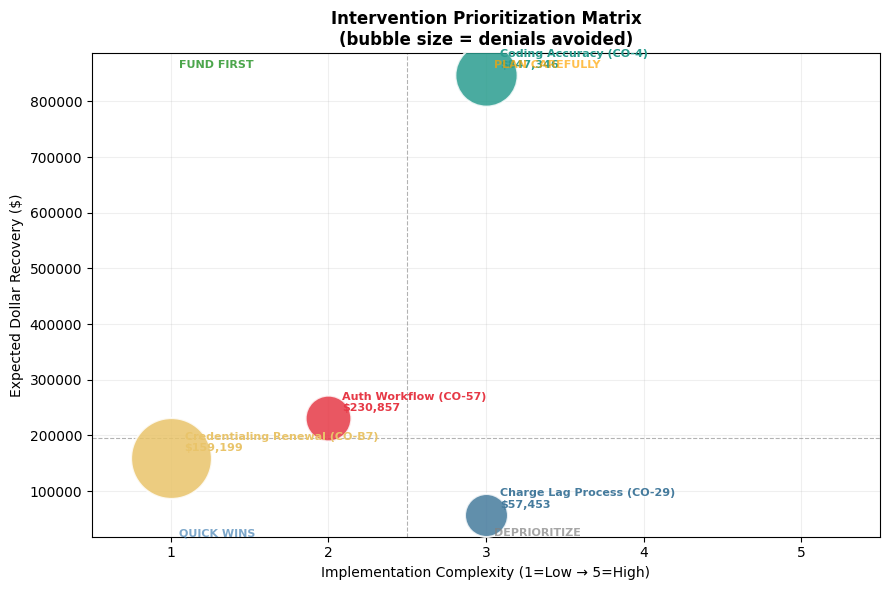

In [16]:
fig, ax = plt.subplots(figsize=(9, 6))

colors_map = {
    "Auth Workflow (CO-57)":         "#e63946",
    "Charge Lag Process (CO-29)":    "#457b9d",
    "Coding Accuracy (CO-4)":        "#2a9d8f",
    "Credentialing Renewal (CO-B7)": "#e9c46a",
}

for _, row in summary.iterrows():
    name   = row["intervention"]
    x      = row["complexity"]
    y      = row["dollars_recovered"]
    size   = max(100, row["denials_avoided"] * 3)
    color  = colors_map.get(name, "steelblue")
    ax.scatter(x, y, s=size, color=color, alpha=0.85, edgecolors="white", linewidth=1.5, zorder=3)
    ax.annotate(
        f"{name}\n${y:,.0f}",
        (x, y), textcoords="offset points", xytext=(10, 5),
        fontsize=8, fontweight="bold", color=color
    )

# Quadrant lines
mid_x = 2.5
mid_y = summary["dollars_recovered"].median()
ax.axvline(mid_x, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.axhline(mid_y, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)

ax.text(1.05, ax.get_ylim()[1] * 0.97, "FUND FIRST", fontsize=8, color="green",
        fontweight="bold", alpha=0.7)
ax.text(3.05, ax.get_ylim()[1] * 0.97, "PLAN CAREFULLY", fontsize=8, color="orange",
        fontweight="bold", alpha=0.7)
ax.text(1.05, ax.get_ylim()[0] * 1.03, "QUICK WINS", fontsize=8, color="steelblue",
        fontweight="bold", alpha=0.7)
ax.text(3.05, ax.get_ylim()[0] * 1.03, "DEPRIORITIZE", fontsize=8, color="gray",
        fontweight="bold", alpha=0.7)

ax.set_xlabel("Implementation Complexity (1=Low → 5=High)", fontsize=10)
ax.set_ylabel("Expected Dollar Recovery ($)", fontsize=10)
ax.set_title("Intervention Prioritization Matrix\n(bubble size = denials avoided)",
             fontsize=12, fontweight="bold")
ax.set_xlim(0.5, 5.5)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()